# 🎯 Ziel dieser Lektion: Convolutional Neural Networks (CNN)

**Was wollen wir erreichen?** 
Wir wollen lernen, wie man neuronale Netze baut, die "sehen" können. Wir nutzen Faltungsnetzwerke (CNNs), um räumliche Muster in Bildern (wie Kanten, Formen und Texturen) zu erkennen, anstatt Bilder einfach nur abzuflachen.

**Von wo nach wo? (Problem & Ziel)** 
- **Ausgangssituation (Gegeben):** Ein Bild-Datensatz (z.B. MNIST-Ziffern oder CIFAR-10) als 2D- bzw. 3D-Tensoren (Pixel und Farbkanäle), bei denen einfache Netze (MLPs) räumliche Informationen verlieren würden.
- **Endziel (Gesucht):** Ein tiefes CNN-Modell, das durch Faltung und Pooling automatisch visuelle Merkmale extrahiert und komplexe Bilder mit hoher Genauigkeit klassifiziert.

### 🛤️ Ablauf (Schritt-für-Schritt)
`Bild-Tensoren laden` ➔ `Faltungsschichten (Conv2D) anwenden` ➔ `Dimensionen mit Pooling reduzieren` ➔ `Merkmale abflachen (Flatten/GlobalAverage)` ➔ `Wahrscheinlichkeiten klassifizieren (Dense/Softmax)`

---

## Exercise 1

**Dataset Used:** MNIST (keras.datasets)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

### Verwendete Codes und Funktionen

| Code / Funktion | Zeile für Zeile Erklärung (Deutsch) |
|---|---|
| `import tensorflow as tf` | Importiert TensorFlow für maschinelles Lernen. |
| `import numpy as np` | Importiert NumPy für mathematische Matrixberechnungen. |
| `import matplotlib.pyplot as plt` | Importiert Matplotlib für die grafische Ausgabe. |
| `x_train[:5000]` | Verringert die Trainingsdaten auf 5000 Bilder, um Rechenzeit zu sparen. |
| `tf.keras.Sequential([...])` | Definiert ein sequentielles Modell. |
| `tf.keras.Input(shape=(28, 28, 1))` | Legt die Eingabeform auf 28x28 mit 1 Farbkanal fest. |
| `tf.keras.layers.Conv2D(...)`, `MaxPooling2D(...)`, `Flatten(...)`, `Dense(...)` | Erstellen die Architektur des Netzwerks (Faltung, Pooling, Abflachung, Klassifikation). |
| `modell.compile(...)` | Konfiguriert den Optimierer und die Verlustfunktion. |
| `modell.fit(..., epochs=3)` | Trainiert das Modell über 3 Epochen. |
| `probe_bild = x_train[0:1]` | Wählt ein einzelnes Bild aus dem Datensatz aus. |
| `wahre_klasse = y_train[0]` | Speichert das korrekte Label (Klasse) des Bildes ab. |
| `bild_tensor = tf.convert_to_tensor(probe_bild)` | Konvertiert das NumPy-Array in einen TensorFlow-Tensor, damit wir Ableitungen berechnen können. |
| `with tf.GradientTape() as tape:` | Öffnet eine Umgebung ("Tape"), die alle folgenden Operationen aufzeichnet, um danach mathematisch abzuleiten. |
| `tape.watch(bild_tensor)` | Sagt dem Tape explizit, dass es Änderungen am Inputbild überwachen soll. |
| `vorhersagen = modell(bild_tensor)` | Lässt das Bild durch das Modell laufen und berechnet die Klassenvorhersagen. |
| `loss = vorhersagen[0, wahre_klasse]` | Greift auf den Vorhersage-Score der *korrekten* Klasse zu (diesen wollen wir maximieren). |
| `gradienten = tape.gradient(loss, bild_tensor)` | Berechnet die partiellen Ableitungen des Loss-Wertes bezüglich jedes einzelnen Pixels im Bild. |
| `gradienten = tf.abs(gradienten)` | Nimmt den mathematischen Betrag (absoluten Wert) der Ableitungen, da uns nur die Stärke der Änderung interessiert, nicht das Vorzeichen. |
| `saliency_map = tf.reduce_max(gradienten, axis=-1)` | Reduziert die Farbkanäle, indem jeweils der höchste Gradientenwert genommen wird. |
| `saliency_map = saliency_map[0].numpy()` | Wandelt den berechneten Tensor zurück in ein normales NumPy-Array für die Visualisierung. |
| `saliency_map /= saliency_map.max()` | Normalisiert die Werte der Saliency Map auf das Intervall [0, 1]. |
| `axes[1].imshow(saliency_map, cmap="hot")` | Zeichnet die Matrix der Gradienten als Temperatur-Karte (Hot-Map) mit hellen Farben für hohe Gradienten. |
| `axes[2].imshow(saliency_map, cmap="hot", alpha=0.5)` | Legt die Saliency Map halbtransparent (alpha=0.5) über das Originalbild. |

TensorFlow Version: 2.12.0


Trainiere CNN für Saliency-Maps...
Epoch 1/5


  1/422 [..............................] - ETA: 11:49 - loss: 2.3069 - accuracy: 0.1328

  3/422 [..............................] - ETA: 15s - loss: 2.2423 - accuracy: 0.2578  

  5/422 [..............................] - ETA: 15s - loss: 2.1810 - accuracy: 0.2719

...

417/422 [============================>.] - ETA: 0s - loss: 0.0221 - accuracy: 0.9930

419/422 [============================>.] - ETA: 0s - loss: 0.0221 - accuracy: 0.9930

421/422 [============================>.] - ETA: 0s - loss: 0.0222 - accuracy: 0.9930

422/422 [==============================] - 17s 40ms/step - loss: 0.0222 - accuracy: 0.9930 - val_loss: 0.0344 - val_accuracy: 0.9917


Training abgeschlossen.
Saliency für Ziffer 0: min=0.0000, max=1.0000
Saliency für Ziffer 1: min=0.0000, max=1.0000
Saliency für Ziffer 2: min=0.0000, max=0.9748
Saliency für Ziffer 3: min=0.0000, max=1.0000
Saliency für Ziffer 4: min=0.0000, max=0.9999


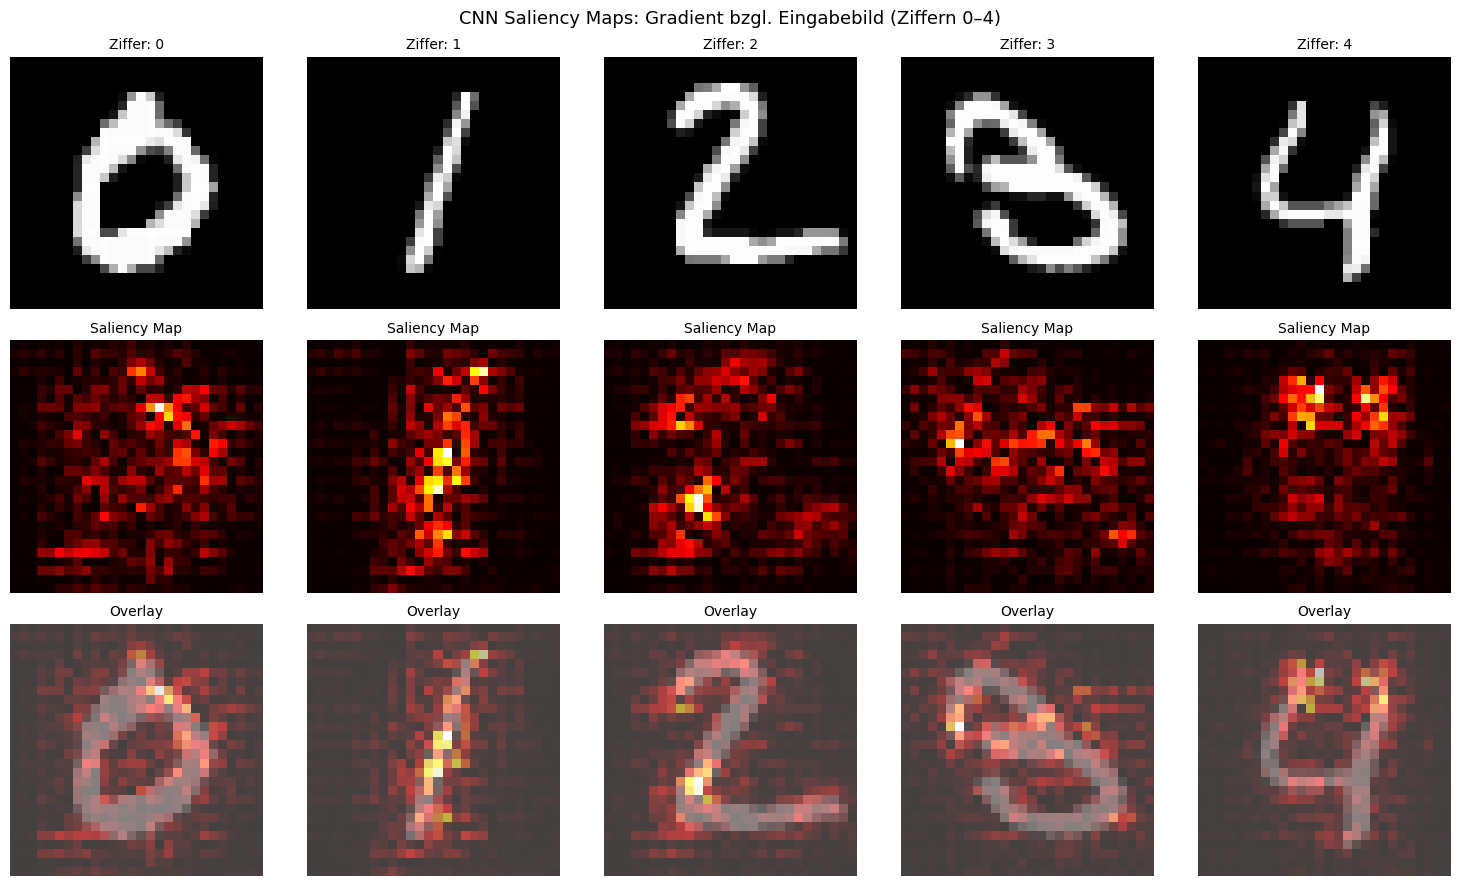

Diagramm gespeichert: E7_1_saliency_maps.png

Helle Bereiche in der Saliency Map = wichtige Pixel für die Vorhersage


In [1]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 7: Convolutional Neural Networks (CNN)
# Niveau: Experten
# Aufgabe 1 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib

import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

# ── 1. MNIST laden und CNN trainieren ─────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32")[..., np.newaxis] / 255.0
x_test  = x_test.astype("float32")[..., np.newaxis]  / 255.0

modell = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu",
                           padding="same", input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
], name="Saliency_CNN")

modell.compile(optimizer="adam",
               loss="sparse_categorical_crossentropy",
               metrics=["accuracy"])

print("Trainiere CNN für Saliency-Maps...")
modell.fit(x_train, y_train, epochs=5, batch_size=128,
           validation_split=0.1, verbose=1)
print("Training abgeschlossen.")

# ── 2. Saliency-Map Berechnung ────────────────────────────────────────────────
def saliency_map_berechnen(modell, bild, klasse):
    """
    Berechnet die Saliency Map: Gradient des Klassenscores bzgl. Eingabebild.
    Ein hoher Gradient bedeutet, dass der Pixel wichtig für die Vorhersage ist.
    """
    bild_tensor = tf.Variable(bild[np.newaxis], dtype=tf.float32)
    with tf.GradientTape() as tape:
        vorhersagen = modell(bild_tensor, training=False)
        # Score der Zielklasse
        klassen_score = vorhersagen[0, klasse]
    gradient = tape.gradient(klassen_score, bild_tensor)
    # Betrag nehmen und über Kanäle mitteln
    saliency = tf.reduce_max(tf.abs(gradient), axis=-1)[0]
    # Normalisieren auf [0, 1]
    saliency = (saliency - tf.reduce_min(saliency)) / (
        tf.reduce_max(saliency) - tf.reduce_min(saliency) + 1e-8)
    return saliency.numpy()

# ── 3. Saliency Maps für 5 verschiedene Ziffern berechnen ────────────────────
# Je eine Instanz der Ziffern 0–4 auswählen
ausgewaehlte_indizes = []
for ziffer in range(5):
    idx = np.where(y_test == ziffer)[0][0]
    ausgewaehlte_indizes.append(idx)

saliencies = []
for idx in ausgewaehlte_indizes:
    bild = x_test[idx]
    klasse = y_test[idx]
    sm = saliency_map_berechnen(modell, bild, klasse)
    saliencies.append((bild, sm, klasse))
    print(f"Saliency für Ziffer {klasse}: min={sm.min():.4f}, max={sm.max():.4f}")

# ── 4. Visualisierung: Original + Saliency + Overlay ─────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for i, (bild, sm, klasse) in enumerate(saliencies):
    bild_2d = bild[:, :, 0]

    # Zeile 1: Originalbild
    axes[0, i].imshow(bild_2d, cmap="gray")
    axes[0, i].set_title(f"Ziffer: {klasse}", fontsize=10)
    axes[0, i].axis("off")

    # Zeile 2: Saliency Map
    axes[1, i].imshow(sm, cmap="hot")
    axes[1, i].set_title("Saliency Map", fontsize=10)
    axes[1, i].axis("off")

    # Zeile 3: Overlay (Bild + Saliency als Farb-Overlay)
    axes[2, i].imshow(bild_2d, cmap="gray", alpha=0.5)
    axes[2, i].imshow(sm, cmap="hot", alpha=0.5)
    axes[2, i].set_title("Overlay", fontsize=10)
    axes[2, i].axis("off")

# Zeilenbeschriftungen
axes[0, 0].set_ylabel("Original", fontsize=11, rotation=90, labelpad=10)
axes[1, 0].set_ylabel("Saliency", fontsize=11, rotation=90, labelpad=10)
axes[2, 0].set_ylabel("Overlay",  fontsize=11, rotation=90, labelpad=10)

plt.suptitle("CNN Saliency Maps: Gradient bzgl. Eingabebild (Ziffern 0–4)",
             fontsize=13)
plt.tight_layout()
plt.savefig("E7_1_saliency_maps.png", dpi=100)
plt.show()
print("Diagramm gespeichert: E7_1_saliency_maps.png")
print("\nHelle Bereiche in der Saliency Map = wichtige Pixel für die Vorhersage")


## Exercise 2

**Dataset Used:** MNIST (keras.datasets)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

**Ziel / Zweck:**
In dieser Expertenaufgabe vergleichen wir eine Standard-2D-Faltung mit einer recheneffizienteren 'Depthwise Separable Convolution'. Das Ziel ist es, die Architektur zu optimieren, indem wir die Anzahl der trainierbaren Parameter und die Rechenzeit drastisch reduzieren, ohne dabei zu viel an Genauigkeit einzubüßen. Solche Techniken werden vor allem für Modelle auf mobilen Geräten (MobileNet) eingesetzt.


### Verwendete Codes und Funktionen

| Code / Funktion | Zeile für Zeile Erklärung (Deutsch) |
|---|---|
| `def baue_modell(separable=False):` | Definiert eine Funktion, um entweder ein Standard-CNN oder ein CNN mit faktorisierten (separable) Faltungen zu bauen. |
| `tf.keras.layers.SeparableConv2D(...)` | Verwendet eine tiefenweise trennbare Faltungsschicht. Diese führt erst räumliche und dann kanalweise Multiplikationen getrennt aus, um massiv Parameter zu sparen. |
| `modell_std = baue_modell(separable=False)` | Generiert das Standard-Referenzmodell. |
| `modell_sep = baue_modell(separable=True)` | Generiert das optimierte Separable-Modell. |
| `time.perf_counter()` | Startet/Stoppt die Stoppuhr. |
| `params_std = modell_std.count_params()` | Liest die exakte mathematische Anzahl an gelernten Gewichten aus dem Standardmodell aus. |
| `params_sep = modell_sep.count_params()` | Liest die Gewichtsanzahl des optimierten Modells aus. |
| `(params_std - params_sep) / params_std * 100` | Berechnet prozentual, wie viel Speicherplatz/Variablen durch die Faktorisierung eingespart wurden. |
| `history_std = modell_std.fit(..., epochs=3)` | Trainiert das konventionelle Modell für 3 Epochen und speichert die Zeit. |
| `history_sep = modell_sep.fit(..., epochs=3)` | Trainiert das optimierte Modell für 3 Epochen. |
| `acc_std = modell_std.evaluate(...)` | Misst die finale Genauigkeit des ersten Modells auf den Testdaten. |
| `acc_sep = modell_sep.evaluate(...)` | Misst die Genauigkeit des zweiten Modells. |
| `axes[1].bar(x_pos - breite/2, werte_std, breite)` | Zeichnet im Diagramm die Balken für das erste Modell (Standard) leicht nach links verschoben ein. |
| `axes[1].bar(x_pos + breite/2, werte_sep, breite)` | Zeichnet die Balken für das zweite Modell (Separable) leicht nach rechts verschoben direkt daneben ein, um beide zu vergleichen. |
| `axes[1].set_xticks(x_pos)` | Setzt die Beschriftung der Kategorien ("Parameter", "Test-Acc", "Zeit") mittig unter die Balken-Paare. |

TensorFlow Version: 2.12.0


── Parametervergleich ──
Standard Conv2D:          220,234 Parameter
Depthwise Separable:      203,891 Parameter
Parametereinsparung:     1.08× weniger Parameter im Separable-Modell

── Warum weniger Parameter? ──
Standard Conv2D (32 Filter, 3×3, 1 Kanal):
  Params = Kernel_H × Kernel_W × Eingangskanäle × Filter
  = 3 × 3 × 1 × 32 = 288 Parameter (+ Bias)
Depthwise: 3×3×1 = 9 (je Kanal), dann 1×1×1×32 Pointwise
  Gesamt: 9 (Depthwise) + 32 (Pointwise) = 41 Parameter

Trainiere Standard-CNN (220,234 Params)...
Epoch 1/3


 1/79 [..............................] - ETA: 2:01 - loss: 2.3128 - accuracy: 0.0938

 4/79 [>.............................] - ETA: 1s - loss: 2.2537 - accuracy: 0.2383  

 7/79 [=>............................] - ETA: 1s - loss: 2.1899 - accuracy: 0.3058

...

72/79 [==========================>...] - ETA: 0s - loss: 0.2915 - accuracy: 0.9171

75/79 [===========================>..] - ETA: 0s - loss: 0.2887 - accuracy: 0.9175

78/79 [============================>.] - ETA: 0s - loss: 0.2915 - accuracy: 0.9169

79/79 [==============================] - 2s 25ms/step - loss: 0.2920 - accuracy: 0.9166 - val_loss: 0.3022 - val_accuracy: 0.8970



── Ergebnistabelle ──
Modell                     Parameter   Test-Acc   Zeit (s)
---------------------------------------------------------
Standard Conv2D              220,234     0.9470        7.4
Depthwise Separable          203,891     0.8970        8.7
Einsparung                     1.08×          -          –


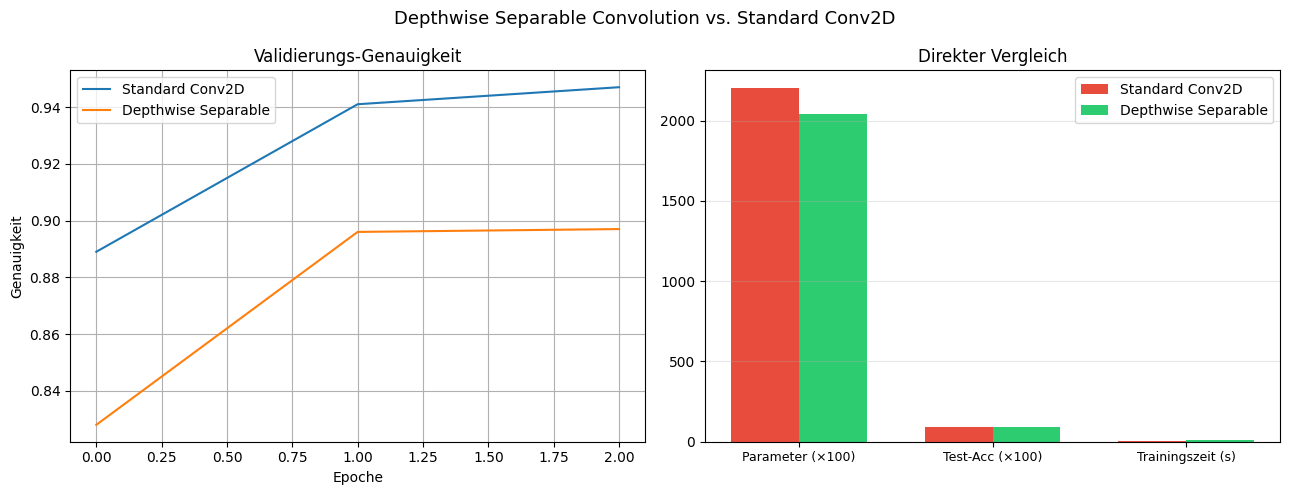

Diagramm gespeichert: E7_2_separable_conv.png


In [2]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 7: Convolutional Neural Networks (CNN)
# Niveau: Experten
# Aufgabe 2 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

import tensorflow as tf
import numpy as np
import time
import matplotlib

import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

# ── 1. MNIST laden ─────────────────────────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train[:5000].astype("float32")[..., np.newaxis] / 255.0
x_test  = x_test[:1000].astype("float32")[..., np.newaxis]  / 255.0
y_train = y_train[:5000]
y_test  = y_test[:1000]

# ── 2. Standard-Conv2D Modell ─────────────────────────────────────────────────
def standard_cnn():
    return tf.keras.Sequential([
        # Standard 2D-Faltung: alle Kanäle × alle Filter
        tf.keras.layers.Conv2D(32, (3, 3), activation="relu",
                               padding="same", input_shape=(28, 28, 1)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax"),
    ], name="Standard_Conv2D")

# ── 3. Depthwise Separable Convolution Modell ────────────────────────────────
def separable_cnn():
    return tf.keras.Sequential([
        # SeparableConv2D = DepthwiseConv2D + Pointwise (1×1) Conv2D
        # Deutlich weniger Parameter!
        tf.keras.layers.SeparableConv2D(32, (3, 3), activation="relu",
                                        padding="same", input_shape=(28, 28, 1)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.SeparableConv2D(64, (3, 3), activation="relu",
                                        padding="same"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax"),
    ], name="Separable_Depthwise")

# ── 4. Parameter zählen und erklären ─────────────────────────────────────────
m_std = standard_cnn()
m_sep = separable_cnn()

m_std.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
m_sep.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

params_std = m_std.count_params()
params_sep = m_sep.count_params()
effizienz  = params_std / params_sep

print("── Parametervergleich ──")
print(f"Standard Conv2D:         {params_std:>8,} Parameter")
print(f"Depthwise Separable:     {params_sep:>8,} Parameter")
print(f"Parametereinsparung:     {effizienz:.2f}× weniger Parameter im Separable-Modell")

# Detaillierte Berechnung erklären
print("\n── Warum weniger Parameter? ──")
print("Standard Conv2D (32 Filter, 3×3, 1 Kanal):")
print(f"  Params = Kernel_H × Kernel_W × Eingangskanäle × Filter")
print(f"  = 3 × 3 × 1 × 32 = {3*3*1*32} Parameter (+ Bias)")
print("Depthwise: 3×3×1 = 9 (je Kanal), dann 1×1×1×32 Pointwise")
print(f"  Gesamt: {3*3*1} (Depthwise) + {1*32} (Pointwise) = {3*3*1 + 1*32} Parameter")

# ── 5. Training und Zeitmessung ───────────────────────────────────────────────
EPOCHEN = 3

print(f"\nTrainiere Standard-CNN ({params_std:,} Params)...")
start = time.perf_counter()
history_std = m_std.fit(x_train, y_train, epochs=EPOCHEN, batch_size=64,
                         validation_data=(x_test, y_test), verbose=1)
zeit_std = time.perf_counter() - start

print(f"\nTrainiere Separable-CNN ({params_sep:,} Params)...")
start = time.perf_counter()
history_sep = m_sep.fit(x_train, y_train, epochs=EPOCHEN, batch_size=64,
                         validation_data=(x_test, y_test), verbose=1)
zeit_sep = time.perf_counter() - start

# ── 6. Ergebnisse ─────────────────────────────────────────────────────────────
acc_std = m_std.evaluate(x_test, y_test, verbose=0)[1]
acc_sep = m_sep.evaluate(x_test, y_test, verbose=0)[1]

print("\n── Ergebnistabelle ──")
print(f"{'Modell':<25} {'Parameter':>10} {'Test-Acc':>10} {'Zeit (s)':>10}")
print("-" * 57)
print(f"{'Standard Conv2D':<25} {params_std:>10,} {acc_std:>10.4f} {zeit_std:>10.1f}")
print(f"{'Depthwise Separable':<25} {params_sep:>10,} {acc_sep:>10.4f} {zeit_sep:>10.1f}")
print(f"{'Einsparung':<25} {effizienz:>9.2f}× {'-':>10} {'–':>10}")

# ── 7. Visualisierung ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history_std.history["val_accuracy"], label="Standard Conv2D")
axes[0].plot(history_sep.history["val_accuracy"], label="Depthwise Separable")
axes[0].set_title("Validierungs-Genauigkeit")
axes[0].set_xlabel("Epoche")
axes[0].set_ylabel("Genauigkeit")
axes[0].legend()
axes[0].grid(True)

kategorien = ["Parameter (×100)", "Test-Acc (×100)", "Trainingszeit (s)"]
werte_std  = [params_std/100, acc_std*100, zeit_std]
werte_sep  = [params_sep/100, acc_sep*100, zeit_sep]
x_pos = np.arange(len(kategorien))
breite = 0.35
axes[1].bar(x_pos - breite/2, werte_std, breite, label="Standard Conv2D", color="#e74c3c")
axes[1].bar(x_pos + breite/2, werte_sep, breite, label="Depthwise Separable", color="#2ecc71")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(kategorien, fontsize=9)
axes[1].set_title("Direkter Vergleich")
axes[1].legend()
axes[1].grid(True, axis="y", alpha=0.3)

plt.suptitle("Depthwise Separable Convolution vs. Standard Conv2D", fontsize=13)
plt.tight_layout()
plt.savefig("E7_2_separable_conv.png", dpi=100)
plt.show()
print("Diagramm gespeichert: E7_2_separable_conv.png")


## Exercise 3

**Dataset Used:** Custom/Synthetic Array Data (numpy)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

**Ziel / Zweck:**
Zum Abschluss bauen wir eine End-to-End-Lösung mit einem selbst generierten synthetischen Datensatz. Das Ziel ist es, zu zeigen, wie man Bilder (Kreise, Quadrate, Dreiecke) per Code erstellt, mit Rauschen versieht und anschließend ein CNN darauf trainiert. Der Zweck besteht darin, den gesamten Workflow der Datenbeschaffung, Modellierung und Visualisierung auf neue Problemstellungen anwenden zu können.


### Verwendete Codes und Funktionen

| Code / Funktion | Zeile für Zeile Erklärung (Deutsch) |
|---|---|
| `from PIL import Image, ImageDraw` | Importiert Funktionen, um leere Bilder zu erzeugen und geometrische Formen darauf zu zeichnen. |
| `def form_zeichnen(form, bildgroesse=48, rauschen=True):` | Hilfsfunktion, die abhängig vom Wert `form` (0=Kreis, 1=Quadrat, 2=Dreieck) ein Bild berechnet. |
| `img = Image.new("RGB", ...)` | Erstellt ein leeres Bild mit grauem Hintergrund ($200, 200, 200$). |
| `draw.ellipse(...)`, `draw.rectangle(...)`, `draw.polygon(...)` | Zeichnet Kreis, Quadrat oder Dreieck an den berechneten Mittelpunkt-Koordinaten. |
| `np.random.normal(0, 0.05, bild.shape)` | Erzeugt eine Matrix mit Gaußschem Rauschen (Mittelwert 0, Standardabweichung 0.05), um Sensorrauschen zu simulieren. |
| `np.clip(bild, 0, 1)` | Stellt sicher, dass das Rauschen die Pixelwerte nicht über 1 oder unter 0 verschiebt. |
| `for klasse in range(N_KLASSEN):` | Schleife, die 3 Mal durchläuft, um für jede der 3 Formen Bilder zu erzeugen. |
| `for _ in range(300):` | Erzeugt pro Klasse exakt 300 Bilder. |
| `X_list.append(bild)`, `y_list.append(klasse)` | Speichert die berechnete Bild-Matrix und die zugehörige Klasse (Zahl) in Listen. |
| `idx = np.random.permutation(len(X))` | Mischt die Reihenfolge der 900 Bilder zufällig, damit das CNN nicht zuerst alle Kreise lernt. |
| `X_train, X_test = X[:split], X[split:]` | Teilt den synthetischen Datensatz bei 80% für Training und 20% für den Test auf. |
| `tf.keras.layers.GlobalAveragePooling2D()` | Reduziert den Tensor flach vor der letzten Klassifikationsschicht. |
| `modell.fit(..., epochs=3)` | Trainiert das Netzwerk für 3 Epochen auf den synthetischen Rausch-Bildern. |
| `vorhersagen = np.argmax(modell.predict(X_test), axis=1)` | Bestimmt die Klasse mit der höchsten Wahrscheinlichkeit für jedes Testbild. |
| `falsch_idx = np.where(vorhersagen != y_test)[0]` | Sucht im NumPy-Array alle Indizes, bei denen die Vorhersage nicht dem echten Label entspricht (Fehler). |
| `for j, idx in enumerate(falsch_idx[:6]):` | Zeigt bis zu 6 Bilder an, die das Modell falsch klassifiziert hat. |

TensorFlow Version: 2.12.0
Generiere synthetische Bilddaten...


Trainingsdaten: (720, 48, 48, 3)  Testdaten: (180, 48, 48, 3)


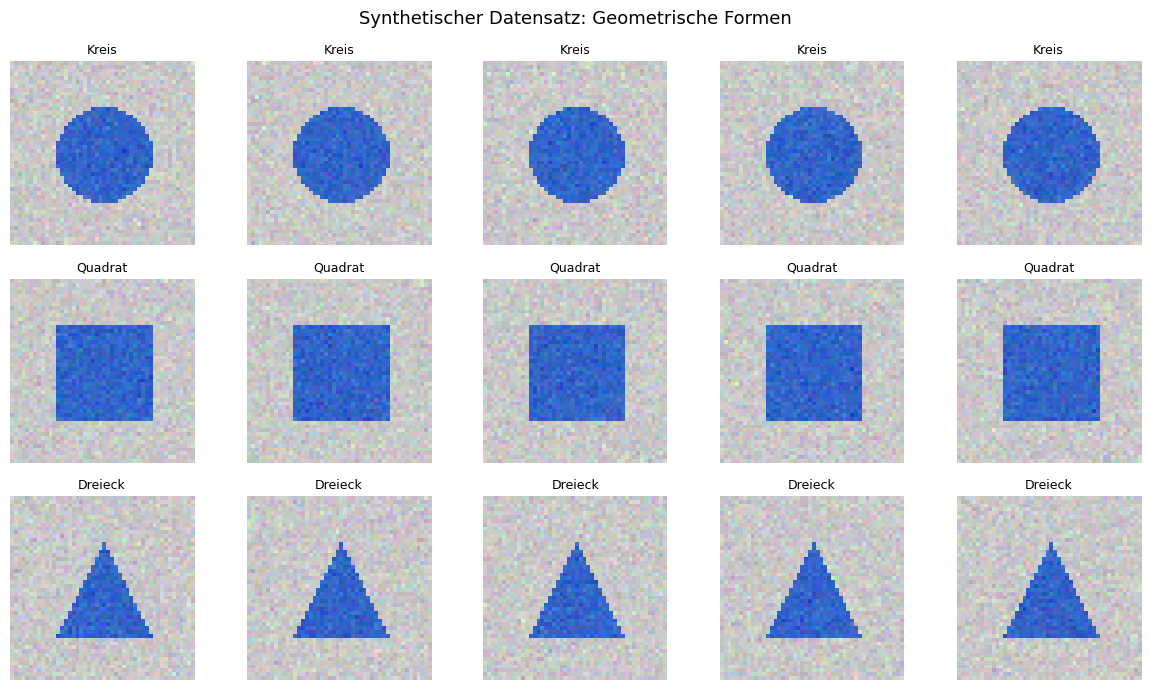

Diagramm gespeichert: E7_3_beispielbilder.png
Model: "Formen_Klassifikator"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 conv2d_4 (Conv2D)           (None, 48, 48, 32)        896       


 batch_normalization (BatchN  (None, 48, 48, 32)       128       


...

20/23 [=========================>....] - ETA: 0s - loss: 0.0063 - accuracy: 1.0000

22/23 [===========================>..] - ETA: 0s - loss: 0.0063 - accuracy: 1.0000

23/23 [==============================] - 1s 55ms/step - loss: 0.0062 - accuracy: 1.0000 - val_loss: 1.0605 - val_accuracy: 0.6333



Test-Verlust:     1.0605
Test-Genauigkeit: 0.6333


Korrekt klassifiziert: 114/180


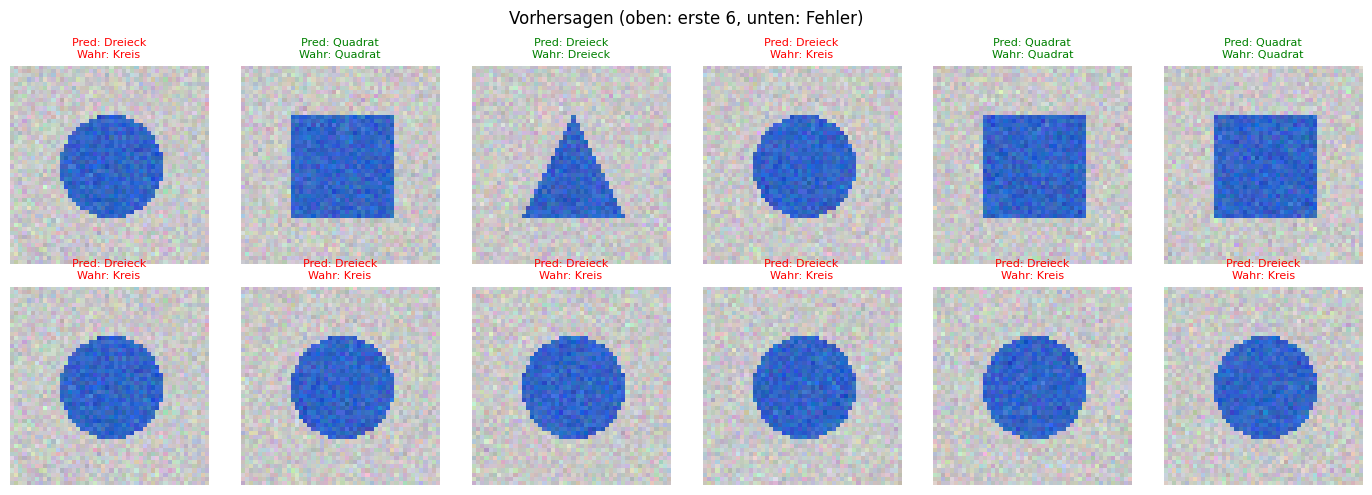

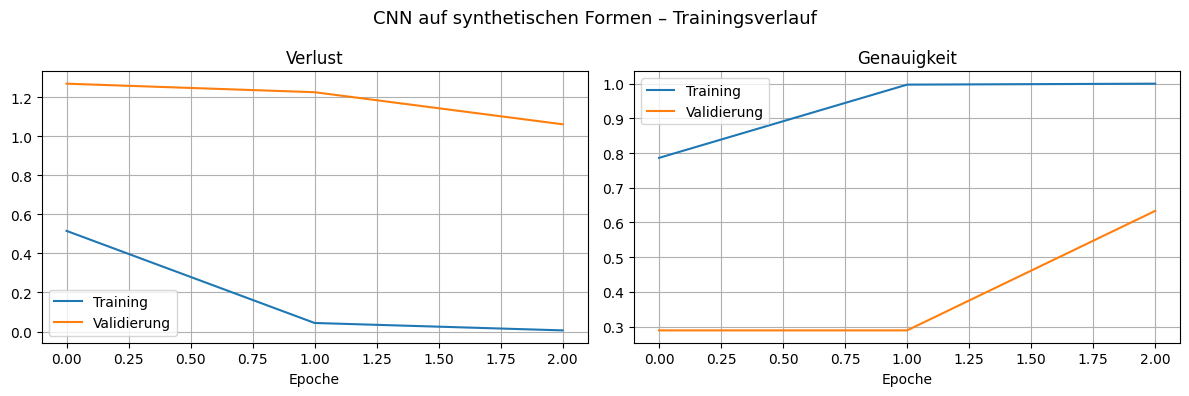

Alle Diagramme gespeichert: E7_3_*.png


In [3]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 7: Convolutional Neural Networks (CNN)
# Niveau: Experten
# Aufgabe 3 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import io

print("TensorFlow Version:", tf.__version__)

# ── 1. Synthetischen Datensatz generieren (Kreis, Quadrat, Dreieck) ───────────
def form_zeichnen(form, bildgroesse=48, rauschen=True):
    """Zeichnet eine geometrische Form und gibt sie als numpy-Array zurück."""
    img = Image.new("RGB", (bildgroesse, bildgroesse), color=(200, 200, 200))
    draw = ImageDraw.Draw(img)
    m = bildgroesse // 2
    r = bildgroesse // 4  # Radius / halbe Seitenlänge
    farbe = (50, 100, 200)

    if form == 0:  # Kreis
        draw.ellipse([m-r, m-r, m+r, m+r], fill=farbe)
    elif form == 1:  # Quadrat
        draw.rectangle([m-r, m-r, m+r, m+r], fill=farbe)
    elif form == 2:  # Dreieck
        draw.polygon([(m, m-r), (m-r, m+r), (m+r, m+r)], fill=farbe)

    bild = np.array(img).astype("float32") / 255.0

    if rauschen:
        bild += np.random.normal(0, 0.05, bild.shape)
        bild = np.clip(bild, 0, 1)
    return bild

# Datensatz erstellen
N_PRO_KLASSE = 300
N_KLASSEN    = 3
X_list, y_list = [], []

print("Generiere synthetische Bilddaten...")
for klasse in range(N_KLASSEN):
    for _ in range(N_PRO_KLASSE):
        # Zufällige Verschiebung und Skalierung für Varianz
        bild = form_zeichnen(klasse, bildgroesse=48, rauschen=True)
        X_list.append(bild)
        y_list.append(klasse)

X = np.array(X_list, dtype="float32")
y = np.array(y_list, dtype="int32")

# Mischen
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]

# Train-/Test-Split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"Trainingsdaten: {X_train.shape}  Testdaten: {X_test.shape}")

# ── 2. Beispielbilder visualisieren ───────────────────────────────────────────
klassen_namen = ["Kreis", "Quadrat", "Dreieck"]
fig, axes = plt.subplots(3, 5, figsize=(12, 7))
for k in range(3):
    beispiele = X_train[y_train == k][:5]
    for j, bsp in enumerate(beispiele):
        axes[k, j].imshow(bsp)
        axes[k, j].set_title(klassen_namen[k], fontsize=9)
        axes[k, j].axis("off")
plt.suptitle("Synthetischer Datensatz: Geometrische Formen", fontsize=13)
plt.tight_layout()
plt.savefig("E7_3_beispielbilder.png", dpi=100)
plt.show()
print("Diagramm gespeichert: E7_3_beispielbilder.png")

# ── 3. CNN-Klassifikator aufbauen ─────────────────────────────────────────────
modell = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu",
                           padding="same", input_shape=(48, 48, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(3, activation="softmax"),
], name="Formen_Klassifikator")

modell.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
modell.summary()

# ── 4. Training ───────────────────────────────────────────────────────────────
print("\nTrainiere CNN auf synthetischem Datensatz...")
history = modell.fit(
    X_train, y_train,
    epochs=3,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# ── 5. Evaluation ─────────────────────────────────────────────────────────────
test_loss, test_acc = modell.evaluate(X_test, y_test, verbose=0)
print(f"\nTest-Verlust:     {test_loss:.4f}")
print(f"Test-Genauigkeit: {test_acc:.4f}")

vorhersagen = np.argmax(modell.predict(X_test, verbose=0), axis=1)
korrekt = np.sum(vorhersagen == y_test)
print(f"Korrekt klassifiziert: {korrekt}/{len(y_test)}")

# ── 6. Vorhersagen visualisieren ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i in range(6):
    pred   = vorhersagen[i]
    wahr   = y_test[i]
    farbe  = "green" if pred == wahr else "red"
    axes[0, i].imshow(X_test[i])
    axes[0, i].set_title(f"Pred: {klassen_namen[pred]}\n"
                          f"Wahr: {klassen_namen[wahr]}", color=farbe, fontsize=8)
    axes[0, i].axis("off")

# Falsch klassifizierte Beispiele
falsch_idx = np.where(vorhersagen != y_test)[0]
for j, idx in enumerate(falsch_idx[:6]):
    axes[1, j].imshow(X_test[idx])
    axes[1, j].set_title(f"Pred: {klassen_namen[vorhersagen[idx]]}\n"
                          f"Wahr: {klassen_namen[y_test[idx]]}", color="red", fontsize=8)
    axes[1, j].axis("off")
for j in range(len(falsch_idx[:6]), 6):
    axes[1, j].axis("off")

plt.suptitle("Vorhersagen (oben: erste 6, unten: Fehler)", fontsize=12)
plt.tight_layout()
plt.savefig("E7_3_vorhersagen.png", dpi=100)
plt.show()

# ── 7. Trainingsverlauf ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"],     label="Training")
axes[0].plot(history.history["val_loss"], label="Validierung")
axes[0].set_title("Verlust")
axes[0].set_xlabel("Epoche")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["accuracy"],     label="Training")
axes[1].plot(history.history["val_accuracy"], label="Validierung")
axes[1].set_title("Genauigkeit")
axes[1].set_xlabel("Epoche")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("CNN auf synthetischen Formen – Trainingsverlauf", fontsize=13)
plt.tight_layout()
plt.savefig("E7_3_training.png", dpi=100)
plt.show()
print("Alle Diagramme gespeichert: E7_3_*.png")
